# Custom Signal Providers and Advanced Context Methods

This notebook covers two topics not shown in the earlier walkthrough notebooks:

1. **The `SignalProvider` protocol** -- how to implement your own signal provider beyond
   `CsvSignalProvider`. Useful when your data comes from a DataFrame, a database, or an
   in-house model rather than a CSV file.

2. **Advanced `TradingContext` methods** -- `get_signal_history()` for lookback windows,
   `get_delivery_position()` for aggregated position views, and gate closure NOP analysis
   from `BacktestResult`.

**Prerequisites:** `backtester_walkthrough.ipynb` (especially the signal system section)


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import date, datetime, timedelta, timezone
from decimal import Decimal

# Import nexa_backtest top-level first so the full package initialises before
# any submodule imports (avoids a circular-import edge case during partial init).
from nexa_backtest import BacktestEngine

FIXTURES_DIR = Path("../tests/fixtures")
DA_DATA_DIR  = FIXTURES_DIR               # contains da_prices.parquet

print("Fixture directory:", DA_DATA_DIR.resolve())
print("Exists:", DA_DATA_DIR.exists())

Fixture directory: /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures
Exists: True


## 1. Why Custom Signal Providers?

`CsvSignalProvider` is convenient when your data is already in CSV format. But in practice,
signal data often comes from sources that don't fit neatly into a CSV file:

- A model that outputs a pandas DataFrame in memory
- A database query result
- An API response that needs pre-processing
- A composite signal derived from multiple other signals

The `SignalProvider` **protocol** defines the minimal interface any provider must implement.
Once you implement it, the backtest engine treats your provider identically to
`CsvSignalProvider`.


## 2. The `SignalProvider` Protocol

A Python `Protocol` is a structural interface -- you don't need to subclass it, you just
implement the required methods. The engine uses duck typing to verify compliance at runtime.


In [2]:
# The SignalProvider protocol lives in nexa_backtest.signals.base
from nexa_backtest.signals.base import SignalProvider, SignalSchema, SignalValue

# A protocol in Python is a structural interface -- you don't subclass it,
# you just implement the required attributes and methods.
# The three things every SignalProvider must have:

print("SignalProvider requires:")
print("  name       (property) -> str")
print("  schema     (property) -> SignalSchema")
print("  get_value  (method)   -> SignalValue")
print("  get_range  (method)   -> pd.Series")
print("  get_history_at (method) -> list[SignalValue]")

SignalProvider requires:
  name       (property) -> str
  schema     (property) -> SignalSchema
  get_value  (method)   -> SignalValue
  get_range  (method)   -> pd.Series
  get_history_at (method) -> list[SignalValue]


### `SignalSchema` -- signal metadata

`SignalSchema` is a simple dataclass that carries metadata about a signal.
The engine uses it for display and validation; it does not affect data loading.


In [3]:
# SignalSchema carries metadata about the signal (unit, frequency, etc.)
from nexa_backtest.signals.base import SignalSchema
import inspect
print(inspect.getsource(SignalSchema))

class SignalSchema(BaseModel):
    """Describes the structure and semantics of a signal.

    Attributes:
        name: Signal identifier, e.g. ``"wind_generation_forecast"``.
        dtype: Python type of the value field, e.g. ``float``.
        frequency: How often the signal updates, e.g. ``timedelta(minutes=15)``.
        description: Human-readable description of what the signal represents.
        unit: Physical unit of the value, e.g. ``"EUR/MWh"``, ``"MW"``, ``"m/s"``.
    """

    model_config = ConfigDict(frozen=True)

    name: str
    dtype: type[Any]
    frequency: timedelta
    description: str
    unit: str



### `SignalValue` -- a single timestamped observation

`SignalValue` is what `get_value()` returns: a name, a timestamp, and a float value.
The timestamp is the **delivery** timestamp (when the value applies), not the publication time.


In [4]:
# SignalValue is what get_value() returns
from nexa_backtest.signals.base import SignalValue
import inspect
print(inspect.getsource(SignalValue))

class SignalValue(BaseModel):
    """A single timestamped signal observation.

    Attributes:
        name: Signal identifier, e.g. ``"wind_generation_forecast"``.
        timestamp: Timezone-aware time this value is valid for.
        value: Numeric signal value. Units depend on the signal definition.
    """

    model_config = ConfigDict(frozen=True)

    name: str
    timestamp: datetime
    value: float



## 3. Building a Custom Provider

We will implement a `DataFrameSignalProvider` -- a provider backed by a pandas DataFrame.

The key method to implement correctly is `get_value(timestamp)`. It must:
1. Filter to values whose **publication time** is at or before `timestamp`
2. Return the most recent among those

With `publication_offset=timedelta(hours=36)`:
- A value for delivery time `T` was published at `T - 36h`
- It becomes visible when `simulated_clock >= T - 36h`
- Which rearranges to: `T <= simulated_clock + 36h`


In [5]:
# We will build a custom provider backed by a pandas DataFrame.
#
# Use case: your team runs a proprietary load forecast model in-house.
# The model outputs a pandas DataFrame (indexed by delivery timestamp)
# that you want to feed into the backtest as a signal.
#
# The provider must:
# 1. Implement the three required methods (name, schema, get_value)
# 2. Respect publication_offset so the algo never sees future values

class DataFrameSignalProvider:
    """A SignalProvider backed by a pandas DataFrame.

    The DataFrame must have a DatetimeIndex (timezone-aware) and a column
    named 'value'. The publication_offset controls when values become visible
    to the algo: a value for delivery time T is published at T - offset, so
    it becomes visible when the simulated clock reaches that publication time.

    Args:
        name: Signal identifier used in ctx.get_signal() and subscribe_signal().
        df: DataFrame with a DatetimeIndex and a 'value' column.
        unit: Physical unit string (e.g. 'EUR/MWh', 'MW', '%').
        description: Human-readable description.
        frequency: How often the signal updates (e.g. timedelta(minutes=15)).
        publication_offset: How far before delivery the forecast is published.
            None means values are available at their delivery timestamp (actuals).
    """

    def __init__(
        self,
        name: str,
        df: pd.DataFrame,
        unit: str = "",
        description: str = "",
        frequency: timedelta = timedelta(minutes=15),
        publication_offset: timedelta | None = None,
    ) -> None:
        self._name = name
        self._df = df.sort_index()   # ensure chronological order
        self._publication_offset = publication_offset
        self._schema = SignalSchema(
            name=name,
            dtype=float,
            frequency=frequency,
            unit=unit,
            description=description,
        )

    @property
    def name(self) -> str:
        return self._name

    @property
    def schema(self) -> SignalSchema:
        return self._schema

    def get_value(self, timestamp: datetime) -> SignalValue:
        """Return the latest value visible at the given simulated time.

        Applies publication_offset: a value for delivery time T was
        published at T - offset, so it is visible when
            current_time >= T - offset
        which rearranges to:
            T <= current_time + offset

        Args:
            timestamp: Current simulated time (timezone-aware).

        Returns:
            The most recent SignalValue visible at timestamp.

        Raises:
            ValueError: If no values are available yet.
        """
        if self._publication_offset is not None:
            # Only include values whose publication time <= timestamp.
            # publication_time = delivery_time - offset
            # => delivery_time <= timestamp + offset
            cutoff = timestamp + self._publication_offset
        else:
            # No offset: values available at their delivery timestamp.
            cutoff = timestamp

        # Filter to values whose delivery timestamp <= cutoff
        visible = self._df[self._df.index <= cutoff]

        if visible.empty:
            raise ValueError(
                f"No signal value for '{self._name}' available at {timestamp!r}"
            )

        # Return the most recent visible value
        latest = visible.iloc[-1]
        return SignalValue(
            name=self._name,
            timestamp=visible.index[-1],
            value=float(latest["value"]),
        )

    def get_range(self, start: datetime, end: datetime) -> pd.Series:
        """Return all values in [start, end) without applying publication_offset."""
        mask = (self._df.index >= start) & (self._df.index < end)
        return self._df.loc[mask, "value"]

    def get_history_at(self, timestamp: datetime, lookback: int) -> list[SignalValue]:
        """Return the last `lookback` values visible at `timestamp`."""
        if self._publication_offset is not None:
            cutoff = timestamp + self._publication_offset
        else:
            cutoff = timestamp

        visible = self._df[self._df.index <= cutoff]
        rows = visible.tail(lookback)
        return [
            SignalValue(name=self._name, timestamp=idx, value=float(row["value"]))
            for idx, row in rows.iterrows()
        ]

print("DataFrameSignalProvider class defined.")

DataFrameSignalProvider class defined.


## 4. Synthetic Forecast Data

We build a synthetic DA price forecast by adding noise to the actual clearing prices.
In production, this would come from your model or database.


In [6]:
# Build a synthetic DA price forecast DataFrame.
#
# In a real scenario this would come from your model, a database query,
# or a parquet file. Here we generate synthetic data that mimics realistic
# DA price forecasts (roughly following actual Nord Pool prices with noise).

# Load the DA clearing prices to base the forecast on
da_prices = pd.read_parquet(FIXTURES_DIR / "da_prices.parquet")

# Create a forecast: actual clearing price + random noise (simulates a model).
#
# IMPORTANT: use .values to extract a numpy array before arithmetic.
# If you keep it as a pandas Series, pandas will try to align the data
# by index label when constructing the DataFrame -- but the Series has an
# integer RangeIndex (0, 1, 2, ...) while the target index is datetimes,
# so every row would silently become NaN. .values strips the index away.
rng = np.random.default_rng(seed=42)

price_values = da_prices["price_eur_mwh"].values  # numpy array, no index
noise        = rng.normal(loc=0.0, scale=3.5, size=len(da_prices))
forecast_values = (price_values + noise).clip(min=0)  # prices can't be negative

forecast_df = pd.DataFrame(
    {"value": forecast_values},
    index=da_prices["timestamp"],  # use the timestamps as the DatetimeIndex
)

assert forecast_df["value"].isna().sum() == 0, "NaN values found -- check index alignment!"

print(f"Forecast shape: {forecast_df.shape}")
print(f"Date range:     {forecast_df.index.min()} to {forecast_df.index.max()}")
print(f"NaN values:     {forecast_df['value'].isna().sum()}")
print(f"\nFirst 5 rows:")
print(forecast_df.head())

Forecast shape: (2976, 1)
Date range:     2026-03-01 00:00:00+00:00 to 2026-03-31 23:45:00+00:00
NaN values:     0

First 5 rows:
                               value
timestamp                           
2026-03-01 00:00:00+00:00  38.504246
2026-03-01 00:15:00+00:00  23.061594
2026-03-01 00:30:00+00:00  43.715740
2026-03-01 00:45:00+00:00  46.008641
2026-03-01 01:00:00+00:00  12.903837


## 5. Visualising `publication_offset`

The chart below shows *when* each delivery period's forecast value becomes visible to the
algo. This is the key mechanism that prevents look-ahead bias.

Without `publication_offset`, the algo could see tomorrow's forecast today -- a classic
look-ahead bias mistake that produces unrealistically good backtest results.


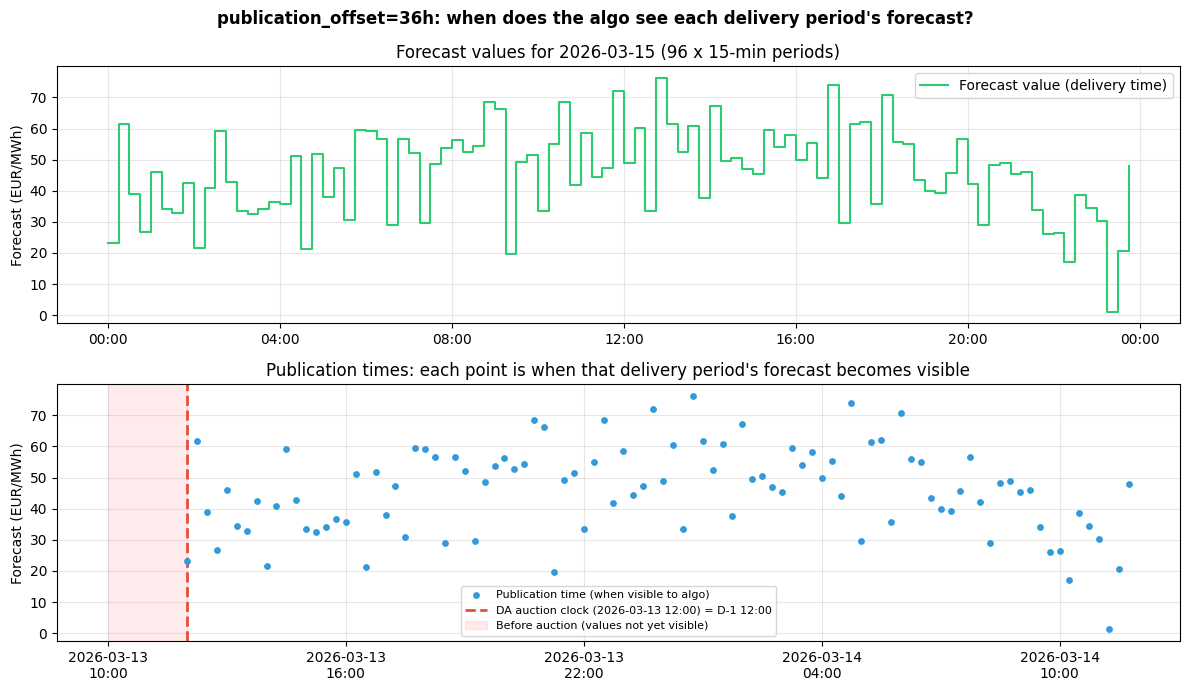


Key insight:
  Delivery day:       2026-03-15
  Forecast published: 2026-03-15 - 36h = 2026-03-13 12:00 UTC
  DA auction clock:   D-1 12:00 UTC = 2026-03-13 12:00 UTC
  At auction time, ALL 96 delivery periods for 2026-03-15 are visible. OK!


In [7]:
# Visualise the publication_offset effect.
#
# With publication_offset=timedelta(hours=36):
#   A forecast value for delivery time T was published at T - 36h.
#   The algo can only see it once the simulated clock reaches T - 36h.
#   At the DA auction (clock = D-1 at ~12:00), all delivery periods
#   for day D become visible (since D-1 12:00 = D 00:00 - 36h).
#
# Without publication_offset (None):
#   Values are available at their delivery timestamp.
#   Using a forecast this way would be LOOK-AHEAD BIAS.

offset = timedelta(hours=36)

# Pick one delivery day to illustrate
delivery_day = pd.Timestamp("2026-03-15", tz="UTC")
day_data = forecast_df[forecast_df.index.date == delivery_day.date()]

# Publication times for this day's values (when they become visible)
pub_times = day_data.index - offset
auction_time = delivery_day - timedelta(hours=36)  # D-1 12:00 UTC

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
fig.suptitle(
    "publication_offset=36h: when does the algo see each delivery period's forecast?",
    fontsize=12, fontweight="bold",
)

# -- Top: forecast values for 2026-03-15 ------------------------------------
ax = axes[0]
ax.step(day_data.index, day_data["value"], where="post",
        color="#2ecc71", linewidth=1.5, label="Forecast value (delivery time)")
ax.set_ylabel("Forecast (EUR/MWh)")
ax.set_title(f"Forecast values for {delivery_day.date()} (96 x 15-min periods)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.grid(alpha=0.3)
ax.legend()

# -- Bottom: publication timeline -------------------------------------------
ax = axes[1]
# Show when each delivery period's forecast becomes visible
ax.scatter(pub_times, day_data["value"], s=15, color="#3498db",
           label="Publication time (when visible to algo)", zorder=3)

# Mark the DA auction time
ax.axvline(x=auction_time, color="#e74c3c", linewidth=2, linestyle="--",
           label=f"DA auction clock ({auction_time.strftime('%Y-%m-%d %H:%M')}) = D-1 12:00")

# Shade the region before the auction (not yet visible)
ax.axvspan(pub_times.min() - timedelta(hours=2), auction_time,
           alpha=0.08, color="red", label="Before auction (values not yet visible)")

ax.set_ylabel("Forecast (EUR/MWh)")
ax.set_title("Publication times: each point is when that delivery period's forecast becomes visible")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insight:")
print(f"  Delivery day:       {delivery_day.date()}")
print(f"  Forecast published: {delivery_day.date()} - 36h = {(delivery_day - offset).strftime('%Y-%m-%d %H:%M')} UTC")
print(f"  DA auction clock:   D-1 12:00 UTC = {auction_time.strftime('%Y-%m-%d %H:%M')} UTC")
print(f"  At auction time, ALL {len(day_data)} delivery periods for {delivery_day.date()} are visible. OK!")

## 6. Wiring into `BacktestEngine`

The custom provider is passed to `BacktestEngine` exactly like `CsvSignalProvider`.
The engine calls `get_value()` at each relevant simulation step.


In [8]:
# Create the provider and run a backtest -- same as CsvSignalProvider
from nexa_backtest import BacktestEngine
from nexa_backtest.algo import SimpleAlgo
from nexa_backtest.context import TradingContext
from nexa_backtest.types import AuctionInfo, Fill
from nexa_backtest import Order


class ForecastAlgo(SimpleAlgo):
    """Buys when our forecast is above the current bid -- expects the price to rise.

    Subscribes to the 'load_forecast' signal in on_setup. At each auction open,
    reads the latest signal value and places a buy if the forecast is above
    a threshold.
    """

    def on_setup(self, ctx: TradingContext) -> None:
        self.subscribe_signal("load_forecast")  # register interest
        self._threshold = Decimal("2.0")       # buy only if forecast - clearing > 2 EUR/MWh

    def on_auction_open(self, ctx: TradingContext, auction: AuctionInfo) -> None:
        try:
            signal = ctx.get_signal("load_forecast")
        except Exception:
            return  # no value available yet

        forecast_price = Decimal(str(signal.value))
        bid_price = forecast_price - self._threshold

        if bid_price > Decimal("0"):
            ctx.place_order(Order.buy(
                product_id=auction.product_id,
                volume_mw=Decimal("5"),
                price_eur_mwh=bid_price,
            ))

    def on_fill(self, ctx: TradingContext, fill: Fill) -> None:
        ctx.log(f"Filled {fill.volume} MW @ {fill.price:.2f} EUR/MWh  [{fill.product_id}]")


# Instantiate our custom provider with a 36-hour publication offset
custom_provider = DataFrameSignalProvider(
    name="load_forecast",
    df=forecast_df,
    unit="EUR/MWh",
    description="Synthetic DA price forecast from DataFrameSignalProvider",
    frequency=timedelta(minutes=15),
    publication_offset=timedelta(hours=36),
)

print("Running backtest with custom DataFrameSignalProvider...")
result = BacktestEngine(
    algo=ForecastAlgo(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 31),
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
    signals=[custom_provider],   # pass like any other SignalProvider
).run()

print("\n" + result.summary())

Running backtest with custom DataFrameSignalProvider...

  Backtest Results: 2026-03-01  to  2026-03-31  (31 days)
  Exchange: nordpool | Algo: ForecastAlgo

  Total PnL:            +32,847.39 EUR
  Market VWAP:               44.79 EUR/MWh
  Sharpe Ratio:              31.27
  Max Drawdown:             -0.00 EUR  (-0.0%)
  Profit Factor:             49.01

  Trades:                      585
  Win Rate:                  90.9%
  Avg Trade PnL:            +56.15 EUR
  Best Trade:             +182.48 EUR  (NO1_20260310T2115Z 2026-03-09 13:00)
  Worst Trade:             -32.14 EUR  (NO1_20260310T1830Z 2026-03-09 13:00)

  Total Volume:            2,925.0 MW
  Initial Capital:      100,000.00 EUR
  Final Equity:         132,847.39 EUR

  Buys
    Fills:         585
    Volume:         2925.0 MWh
    Avg Price:       33.56 EUR/MWh
    vs VWAP:        +11.23 EUR/MWh  (bought below VWAP ✓)
    EUR Alpha:   +32847.39 EUR
    Win Rate:       90.9%

  Total Alpha:   +32847.39 EUR
  Total Fills:    

## 7. Signal History: `get_signal_history()`

`ctx.get_signal_history(name, lookback)` returns the last `lookback` signal values visible
at the current simulated time. This is useful for:

- **Trend following**: compare the current value to an N-period moving average
- **Momentum signals**: look for consecutive up or down movements
- **Warm-up detection**: check that enough history exists before trading

First, let's verify what `get_history_at()` returns on the provider directly,
then use it through `ctx.get_signal_history()` in an algo.


In [9]:
# get_signal_history() returns the last N values visible at the current time.
# This is useful for trend-following or moving-average strategies.
#
# In this example we use a simple 3-period moving average of the forecast
# to smooth out noise before deciding whether to place an order.
#
# NOTE: get_signal_history() is called inside the algo, not here.
#       The code below demonstrates the provider's get_history_at() method
#       directly to show what the algo would see at a specific simulated time.

# Simulated clock time: DA auction for 2026-03-15 (D-1 12:00)
sim_time = datetime(2026, 3, 14, 12, 0, 0, tzinfo=timezone.utc)

# What are the last 5 values visible to the algo at this simulated time?
history = custom_provider.get_history_at(sim_time, lookback=5)

print(f"Signal history visible at {sim_time.isoformat()}:")
print(f"(Only values with publication_time <= {sim_time.isoformat()} are returned)")
print()
for sv in history:
    pub_time = sv.timestamp - timedelta(hours=36)
    print(f"  delivery {sv.timestamp.strftime('%Y-%m-%d %H:%M')} UTC  "
          f"| value = {sv.value:7.2f} EUR/MWh  "
          f"| published {pub_time.strftime('%Y-%m-%d %H:%M')} UTC")

# A moving average over the visible history
values = [sv.value for sv in history]
ma = sum(values) / len(values) if values else None
print(f"\n3-period moving average: {ma:.2f} EUR/MWh" if ma else "No history yet")

Signal history visible at 2026-03-14T12:00:00+00:00:
(Only values with publication_time <= 2026-03-14T12:00:00+00:00 are returned)

  delivery 2026-03-15 23:00 UTC  | value =   30.28 EUR/MWh  | published 2026-03-14 11:00 UTC
  delivery 2026-03-15 23:15 UTC  | value =    1.20 EUR/MWh  | published 2026-03-14 11:15 UTC
  delivery 2026-03-15 23:30 UTC  | value =   20.74 EUR/MWh  | published 2026-03-14 11:30 UTC
  delivery 2026-03-15 23:45 UTC  | value =   47.91 EUR/MWh  | published 2026-03-14 11:45 UTC
  delivery 2026-03-16 00:00 UTC  | value =   27.36 EUR/MWh  | published 2026-03-14 12:00 UTC

3-period moving average: 25.50 EUR/MWh


## 8. Using Signal History in an Algo

Here we use a 3-period moving average of the forecast to smooth noise before placing orders.

A moving average reduces reaction to outliers and can improve signal quality, though it
also introduces lag.


In [10]:
# An algo that uses a 3-period moving average of the signal to smooth noise.
# get_signal_history() is called on ctx (TradingContext), not the provider directly.


class MovingAverageForecastAlgo(SimpleAlgo):
    """Buys when the 3-period moving average of the forecast is above a threshold.

    Using a moving average reduces noise and avoids trading on a single
    noisy forecast value.
    """

    def on_setup(self, ctx: TradingContext) -> None:
        self.subscribe_signal("load_forecast")
        self._threshold = Decimal("2.0")
        self._lookback = 3

    def on_auction_open(self, ctx: TradingContext, auction: AuctionInfo) -> None:
        try:
            history = ctx.get_signal_history("load_forecast", self._lookback)
        except Exception:
            return  # not enough history yet

        if len(history) < self._lookback:
            return  # wait for enough history to compute the MA

        ma = sum(sv.value for sv in history) / len(history)
        bid_price = Decimal(str(ma)) - self._threshold

        if bid_price > Decimal("0"):
            ctx.place_order(Order.buy(
                product_id=auction.product_id,
                volume_mw=Decimal("5"),
                price_eur_mwh=bid_price,
            ))


print("Running backtest with moving average signal algo...")
ma_result = BacktestEngine(
    algo=MovingAverageForecastAlgo(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 31),
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
    signals=[custom_provider],
).run()

print(f"  Fills: {len(ma_result.fills)}")
print(f"  VWAP alpha: {float(ma_result.pnl.total_alpha_eur):+.2f} EUR")

Running backtest with moving average signal algo...
  Fills: 520
  VWAP alpha: +34483.91 EUR


## 9. Delivery Positions: `get_delivery_position()`

`TradingContext` provides two position views:

| Method | Returns |
|--|--|
| `get_position(product_id)` | Position for one specific exchange product |
| `get_delivery_position(delivery_start)` | Aggregated position across all products for one delivery period |

In a DA-only backtest, these are equivalent (one product per delivery period). The
distinction matters in mixed DA + IDC backtests, where multiple products may cover the
same delivery period.


In [11]:
# get_delivery_position() vs get_position()
#
# get_position(product_id) returns the position for one specific product
# (e.g. "NO1_DA" with a specific delivery timestamp).
#
# get_delivery_position(delivery_start) aggregates positions across ALL products
# for a given delivery period. This is useful when you have multiple overlapping
# products covering the same delivery time (e.g. a DA + IDC combination).
#
# In this DA-only backtest there is one product per delivery period,
# so the two calls return equivalent results. The distinction matters more
# in multi-product backtests.

from nexa_backtest.context import TradingContext


class PositionAwareAlgo(SimpleAlgo):
    """Demonstrates get_position vs get_delivery_position.

    Logs both calls at teardown to show the difference in output.
    """

    def on_setup(self, ctx: TradingContext) -> None:
        self.subscribe_signal("load_forecast")

    def on_auction_open(self, ctx: TradingContext, auction: AuctionInfo) -> None:
        try:
            signal = ctx.get_signal("load_forecast")
        except Exception:
            return
        forecast_price = Decimal(str(signal.value))
        ctx.place_order(Order.buy(
            product_id=auction.product_id,
            volume_mw=Decimal("2"),
            price_eur_mwh=forecast_price - Decimal("5"),
        ))

    def on_teardown(self, ctx: TradingContext) -> None:
        positions = ctx.get_all_positions()
        ctx.log(f"\nTotal open positions at teardown: {len(positions)}")

        # Show the first 3 using get_position (per-product)
        for i, (pid, pos) in enumerate(list(positions.items())[:3]):
            ctx.log(
                f"  get_position('{pid}'): "
                f"net_mw={pos.net_mw:+.2f}, avg_entry={pos.avg_entry_price:.2f} EUR/MWh"
            )

        # Show the first 3 delivery periods using get_delivery_position
        delivery_positions = ctx.get_all_delivery_positions()
        ctx.log(f"\nDelivery positions (aggregated): {len(delivery_positions)} delivery periods")
        for i, (delivery_start, dpos) in enumerate(list(delivery_positions.items())[:3]):
            ctx.log(
                f"  get_delivery_position({delivery_start.strftime('%Y-%m-%d %H:%M')}): "
                f"net_mw={dpos.net_mw:+.2f}"
            )


pos_result = BacktestEngine(
    algo=PositionAwareAlgo(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 3),    # short run to keep output tidy
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
    signals=[custom_provider],
).run()
print(f"Fills: {len(pos_result.fills)}")

Fills: 7


## 10. Gate Closure NOP Analysis

After a backtest, `result.gate_closure_positions` contains a snapshot of the net open
position at each gate closure event. This is important for risk management:

- **High NOP at gate closure** = the algo was frequently caught with an open position
  when trading stopped. In live trading, this position must be managed.
- **DA backtests**: NOP is always exactly the filled volume (price-taker, no partial fills
  unless the order exceeds available volume).
- **IDC backtests**: NOP can be non-zero if orders were not matched before gate closure.


In [12]:
# Gate closure NOP (Net Open Position) analysis
#
# After a backtest, result.gate_closure_positions is a tuple of
# GateClosureSnapshot objects -- one for each gate closure event.
# Each snapshot records the net position at the moment the gate closed.
#
# Key metrics:
#   result.avg_gate_closure_nop_mw  -- average NOP at gate closure
#   result.max_gate_closure_nop_mw  -- maximum NOP at gate closure
#
# A high NOP at gate closure means the algo was frequently caught with
# an open position just before trading stopped. This is a risk signal.

from nexa_backtest.analysis.metrics import GateClosureSnapshot

nop_result = result  # use the 31-day result from section 4

print(f"Gate closure events recorded: {len(nop_result.gate_closure_positions)}")
print(f"Average NOP at gate closure:  {float(nop_result.avg_gate_closure_nop_mw):+.3f} MW")
print(f"Maximum NOP at gate closure:  {float(nop_result.max_gate_closure_nop_mw):+.3f} MW")

# Convert to DataFrame for easier analysis
nop_data = [
    {
        "timestamp": snap.timestamp,
        "product_id": snap.product_id,
        "net_mw": float(snap.net_mw),
    }
    for snap in nop_result.gate_closure_positions
]
nop_df = pd.DataFrame(nop_data)
if not nop_df.empty:
    print(f"\nFirst 5 gate closure snapshots:")
    print(nop_df.head())

Gate closure events recorded: 0
Average NOP at gate closure:  +0.000 MW
Maximum NOP at gate closure:  +0.000 MW


In [13]:
# Visualise the distribution of NOP at gate closure events.
#
# Each DA product has a gate closure time (when no further orders are accepted).
# The chart below shows:
#   - Left: distribution of net positions at gate closure
#   - Right: NOP over time (to spot structural patterns)

if nop_df.empty:
    print("No gate closure positions recorded (algo may have had zero fills).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Net Open Position (NOP) at gate closure", fontsize=13, fontweight="bold")

    # -- Left: histogram -------------------------------------------------------
    ax = axes[0]
    ax.hist(nop_df["net_mw"], bins=20, color="#3498db", edgecolor="white", alpha=0.85)
    ax.axvline(x=0, color="#e74c3c", linewidth=1.5, linestyle="--", label="Zero NOP")
    ax.axvline(x=float(nop_result.avg_gate_closure_nop_mw), color="#2ecc71",
               linewidth=1.5, linestyle="--",
               label=f"Mean = {float(nop_result.avg_gate_closure_nop_mw):.3f} MW")
    ax.set_xlabel("NOP (MW) at gate closure")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of NOP at gate closure")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # -- Right: NOP over time --------------------------------------------------
    ax = axes[1]
    ax.scatter(range(len(nop_df)), nop_df["net_mw"], s=12, color="#3498db", alpha=0.6)
    ax.axhline(y=0, color="#e74c3c", linewidth=1, linestyle="--")
    ax.axhline(y=float(nop_result.avg_gate_closure_nop_mw), color="#2ecc71",
               linewidth=1.5, linestyle="--",
               label=f"Mean = {float(nop_result.avg_gate_closure_nop_mw):.3f} MW")
    ax.set_xlabel("Gate closure event (chronological)")
    ax.set_ylabel("NOP (MW)")
    ax.set_title("NOP at each gate closure event over time")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nNOP analysis (DA-only backtest, price-taker matching):")
    print(f"  Mean NOP: {float(nop_result.avg_gate_closure_nop_mw):.4f} MW")
    print(f"  Max NOP:  {float(nop_result.max_gate_closure_nop_mw):.4f} MW")
    print()
    print("In a DA-only backtest with price-taker matching, NOP is always 0 or the")
    print("exact filled volume (no partial fills). IDC strategies with unmatched orders")
    print("at gate closure will show more interesting NOP distributions.")

No gate closure positions recorded (algo may have had zero fills).


## Summary

### Implementing a custom `SignalProvider`

```python
from nexa_backtest.signals.base import SignalProvider, SignalSchema, SignalValue

class MyProvider:
    @property
    def name(self) -> str: return "my_signal"

    @property
    def schema(self) -> SignalSchema:
        return SignalSchema(name="my_signal", dtype=float,
                            frequency=timedelta(minutes=15), unit="EUR/MWh")

    def get_value(self, timestamp: datetime) -> SignalValue:
        # Only return values whose publication time <= timestamp
        cutoff = timestamp + self.publication_offset  # if applicable
        ...

    def get_range(self, start, end) -> pd.Series: ...
    def get_history_at(self, timestamp, lookback) -> list[SignalValue]: ...
```

### Key rules for `get_value()`

1. Apply `publication_offset` as `cutoff = timestamp + offset`
2. Filter to rows with `delivery_timestamp <= cutoff`
3. Return the most recent row as a `SignalValue`

### Advanced context methods

| Method | Use case |
|--|--|
| `ctx.get_signal(name)` | Latest signal value at current simulated time |
| `ctx.get_signal_history(name, n)` | Last N signal values (for MA, momentum) |
| `ctx.get_position(product_id)` | Net position for one product |
| `ctx.get_delivery_position(delivery_start)` | Aggregated position across products for one delivery period |
| `ctx.get_all_delivery_positions()` | All delivery period positions |

### Gate closure NOP

```python
result.gate_closure_positions  # tuple[GateClosureSnapshot, ...]
result.avg_gate_closure_nop_mw  # Decimal -- mean NOP at gate closure
result.max_gate_closure_nop_mw  # Decimal -- max NOP at gate closure

# Convert to DataFrame
pd.DataFrame([
    {"timestamp": s.timestamp, "product_id": s.product_id, "net_mw": float(s.net_mw)}
    for s in result.gate_closure_positions
])
```

### Further reading

- `src/nexa_backtest/signals/base.py` -- SignalProvider protocol definition
- `src/nexa_backtest/signals/csv_loader.py` -- CsvSignalProvider as a reference implementation
- `notebooks/01-backtester_walkthrough.ipynb` -- look-ahead bias and publication_offset intro
